<a href="https://colab.research.google.com/github/auliatauhid/Data-Science-2026/blob/main/Pertemuan4_AuliaTauhid_250401020136.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Aulia Tauhid Akbar - 250401020136 - Data Science IF405**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ============================================================
# LANGKAH 1: Load & Inspect Dataset
# ============================================================

df = sns.load_dataset('iris')
print("=" * 50)
print("LANGKAH 1: Load & Inspect Dataset")
print("=" * 50)
print("Shape:", df.shape)
print("\ndtypes:")
print(df.dtypes)
print("\nhead():")
print(df.head())
print("\ndescribe():")
print(df.describe().round(3))

LANGKAH 1: Load & Inspect Dataset
Shape: (150, 5)

dtypes:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

head():
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

describe():
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         

In [6]:
# ============================================================
# LANGKAH 2: Statistik Deskriptif Lengkap
# ============================================================

print("\n" + "=" * 50)
print("LANGKAH 2: Statistik Deskriptif Lengkap")
print("=" * 50)

for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'\n=== {col_name} ===')
    print(f'  Mean     : {col.mean():.3f}')
    print(f'  Median   : {col.median():.3f}')
    print(f'  Std Dev  : {col.std():.3f}')
    print(f'  Variance : {col.var():.3f}')
    print(f'  Skewness : {col.skew():.3f}')
    print(f'  Kurtosis : {col.kurt():.3f}')


LANGKAH 2: Statistik Deskriptif Lengkap

=== sepal_length ===
  Mean     : 5.843
  Median   : 5.800
  Std Dev  : 0.828
  Variance : 0.686
  Skewness : 0.315
  Kurtosis : -0.552

=== sepal_width ===
  Mean     : 3.057
  Median   : 3.000
  Std Dev  : 0.436
  Variance : 0.190
  Skewness : 0.319
  Kurtosis : 0.228

=== petal_length ===
  Mean     : 3.758
  Median   : 4.350
  Std Dev  : 1.765
  Variance : 3.116
  Skewness : -0.275
  Kurtosis : -1.402

=== petal_width ===
  Mean     : 1.199
  Median   : 1.300
  Std Dev  : 0.762
  Variance : 0.581
  Skewness : -0.103
  Kurtosis : -1.341



LANGKAH 3: Analisis Distribusi — sepal_length


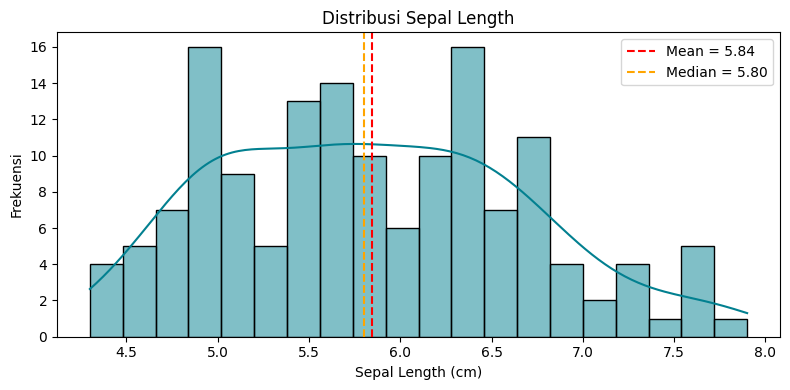

Skewness sepal_length: 0.315 → Right-skewed (positif)


In [7]:
# ============================================================
# LANGKAH 3: Analisis Distribusi (Histogram + KDE)
# ============================================================

print("\n" + "=" * 50)
print("LANGKAH 3: Analisis Distribusi — sepal_length")
print("=" * 50)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['sepal_length'], kde=True, color='#028090', bins=20, ax=ax)
ax.axvline(df['sepal_length'].mean(),
           color='red', linestyle='--',
           label=f"Mean = {df['sepal_length'].mean():.2f}")
ax.axvline(df['sepal_length'].median(),
           color='orange', linestyle='--',
           label=f"Median = {df['sepal_length'].median():.2f}")
ax.set_title('Distribusi Sepal Length')
ax.set_xlabel('Sepal Length (cm)')
ax.set_ylabel('Frekuensi')
ax.legend()
plt.tight_layout()
plt.savefig('langkah3_distribusi.png', dpi=150)
plt.show()

sk = df['sepal_length'].skew()
if abs(sk) < 0.2:
    dist_type = "Simetris (mendekati normal)"
elif sk > 0:
    dist_type = "Right-skewed (positif)"
else:
    dist_type = "Left-skewed (negatif)"
print(f"Skewness sepal_length: {sk:.3f} → {dist_type}")


LANGKAH 4: Boxplot Petal Length per Spesies


/tmp/ipykernel_2097/3006646559.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='petal_length',
/tmp/ipykernel_2097/3006646559.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y='petal_length',


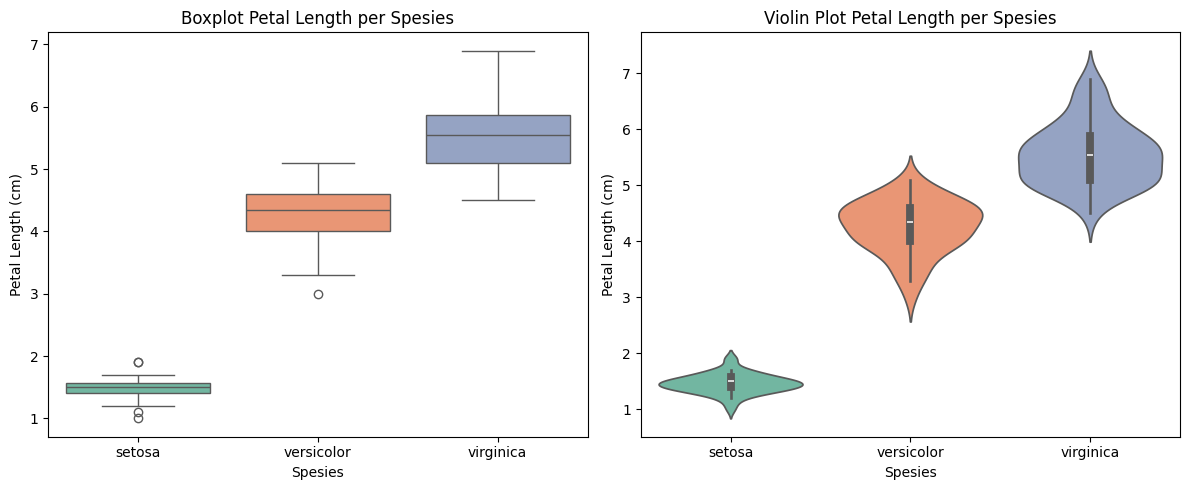


Statistik petal_length per spesies:
             mean  median    std  min  max
species                                   
setosa      1.462    1.50  0.174  1.0  1.9
versicolor  4.260    4.35  0.470  3.0  5.1
virginica   5.552    5.55  0.552  4.5  6.9

Nilai terbesar : virginica
Nilai terkecil : setosa
Paling tersebar: virginica


In [8]:
# ============================================================
# LANGKAH 4: Boxplot per Spesies
# ============================================================

print("\n" + "=" * 50)
print("LANGKAH 4: Boxplot Petal Length per Spesies")
print("=" * 50)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='species', y='petal_length',
            palette='Set2', ax=axes[0])
axes[0].set_title('Boxplot Petal Length per Spesies')
axes[0].set_xlabel('Spesies')
axes[0].set_ylabel('Petal Length (cm)')

sns.violinplot(data=df, x='species', y='petal_length',
               palette='Set2', inner='box', ax=axes[1])
axes[1].set_title('Violin Plot Petal Length per Spesies')
axes[1].set_xlabel('Spesies')
axes[1].set_ylabel('Petal Length (cm)')

plt.tight_layout()
plt.savefig('langkah4_boxplot.png', dpi=150)
plt.show()

# Analisis per spesies
print("\nStatistik petal_length per spesies:")
summary = df.groupby('species')['petal_length'].agg(['mean', 'median', 'std', 'min', 'max'])
print(summary.round(3))

species_max  = summary['mean'].idxmax()
species_min  = summary['mean'].idxmin()
species_spread = summary['std'].idxmax()
print(f"\nNilai terbesar : {species_max}")
print(f"Nilai terkecil : {species_min}")
print(f"Paling tersebar: {species_spread}")

In [9]:
# ============================================================
# LANGKAH 5: Matriks Korelasi Pearson
# ============================================================

print("\n" + "=" * 50)
print("LANGKAH 5: Matriks Korelasi Pearson")
print("=" * 50)

corr = df.drop('species', axis=1).corr(method='pearson')
print(corr.round(3))

mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)

max_pair = corr_masked.stack().idxmax()
min_pair = corr_masked.stack().idxmin()
print(f'\nKorelasi tertinggi : {max_pair} = {corr.loc[max_pair]:.3f}')
print(f'Korelasi terendah  : {min_pair} = {corr.loc[min_pair]:.3f}')


LANGKAH 5: Matriks Korelasi Pearson
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000

Korelasi tertinggi : ('petal_width', 'petal_length') = 0.963
Korelasi terendah  : ('petal_length', 'sepal_width') = -0.428



LANGKAH 6: Scatter Plot & Heatmap Korelasi


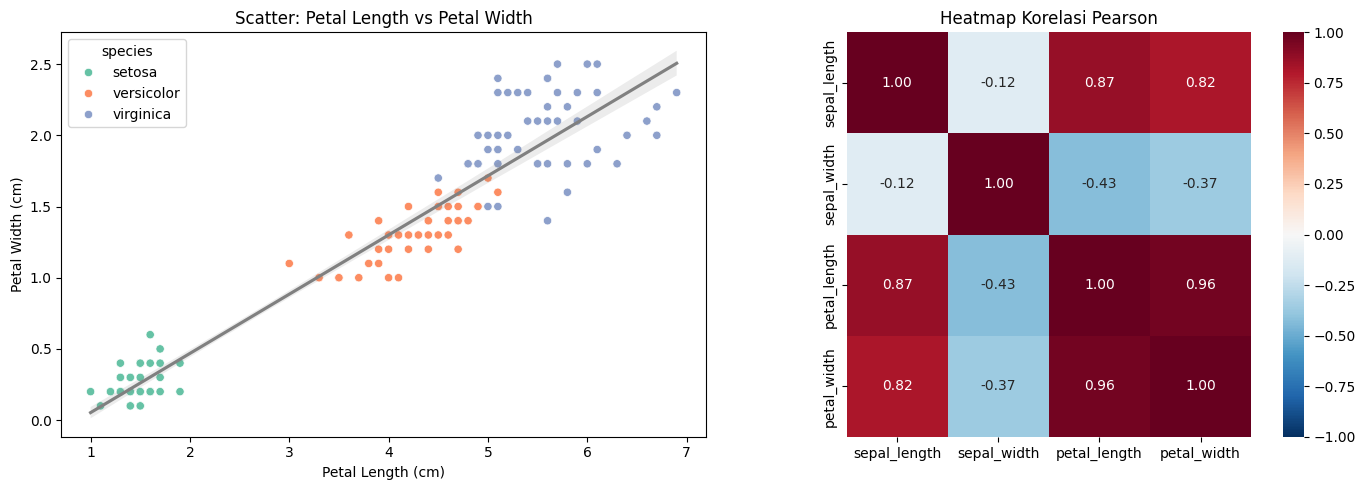


## Interpretasi (Langkah 6)
 
### Scatter Plot: Petal Length vs Petal Width
- Korelasi Pearson r = 0.963 → **korelasi positif sangat kuat**
- Setosa mengelompok terpisah jauh di pojok kiri bawah
- Versicolor dan Virginica saling berdekatan namun masih bisa dibedakan
- Garis regresi menunjukkan tren linear yang jelas
 
### Heatmap Korelasi
- petal_length & petal_width: r = 0.963 (tertinggi)
- sepal_width berkorelasi negatif lemah dengan ketiga fitur petal
- Fitur petal (length & width) lebih informatif untuk klasifikasi
  dibandingkan fitur sepal



In [10]:
# ============================================================
# LANGKAH 6: Scatter Plot & Heatmap + Interpretasi
# ============================================================

print("\n" + "=" * 50)
print("LANGKAH 6: Scatter Plot & Heatmap Korelasi")
print("=" * 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot pasangan paling berkorelasi
sns.scatterplot(data=df, x='petal_length', y='petal_width',
                hue='species', palette='Set2', ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width',
            scatter=False, color='gray', ax=axes[0])
axes[0].set_title('Scatter: Petal Length vs Petal Width')
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')

# Heatmap korelasi
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Heatmap Korelasi Pearson')

plt.tight_layout()
plt.savefig('langkah6_scatter_heatmap.png', dpi=150)
plt.show()

# Interpretasi Markdown (dicetak ke konsol)
r_val = corr.loc['petal_length', 'petal_width']
print(f"""
## Interpretasi (Langkah 6)

### Scatter Plot: Petal Length vs Petal Width
- Korelasi Pearson r = {r_val:.3f} → **korelasi positif sangat kuat**
- Setosa mengelompok terpisah jauh di pojok kiri bawah
- Versicolor dan Virginica saling berdekatan namun masih bisa dibedakan
- Garis regresi menunjukkan tren linear yang jelas

### Heatmap Korelasi
- petal_length & petal_width: r = {r_val:.3f} (tertinggi)
- sepal_width berkorelasi negatif lemah dengan ketiga fitur petal
- Fitur petal (length & width) lebih informatif untuk klasifikasi
  dibandingkan fitur sepal
""")

**Kesimpulan**

